In [3]:
import pandas as pd

# Load the dataset to analyze it
file_path = '/content/shopping_trends.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset for inspection
data.head(), data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

(   Customer ID  Age Gender Item Purchased  Category  Purchase Amount (USD)  \
 0            1   55   Male         Blouse  Clothing                     53   
 1            2   19   Male        Sweater  Clothing                     64   
 2            3   50   Male          Jeans  Clothing                     73   
 3            4   21   Male        Sandals  Footwear                     90   
 4            5   45   Male         Blouse  Clothing                     49   
 
         Location Size      Color  Season  Review Rating Subscription Status  \
 0       Kentucky    L       Gray  Winter            3.1                 Yes   
 1          Maine    L     Maroon  Winter            3.1                 Yes   
 2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
 3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
 4         Oregon    M  Turquoise  Spring            2.7                 Yes   
 
   Payment Method  Shipping Type Discount 

In [5]:
# Question 1: Overall distribution of customer ages in the dataset
age_distribution = data['Age'].describe()
print(age_distribution)

count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64


In [8]:
# Question 2: Average purchase amount by product category
avg_purchase_by_category = data.groupby('Category')['Purchase Amount (USD)'].mean()
print(avg_purchase_by_category)

Category
Accessories    59.838710
Clothing       60.025331
Footwear       60.255426
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64


In [9]:
# Question 3: Gender with the highest number of purchases
gender_purchase_count = data['Gender'].value_counts()
print(gender_purchase_count)

Gender
Male      2652
Female    1248
Name: count, dtype: int64


In [10]:
# Question 4: Most commonly purchased items in each category
most_common_items_by_category = data.groupby('Category')['Item Purchased'].agg(
    lambda x: x.mode().iloc[0])
print(most_common_items_by_category)

Category
Accessories    Jewelry
Clothing        Blouse
Footwear       Sandals
Outerwear       Jacket
Name: Item Purchased, dtype: object


In [11]:
# Question 5: Seasons or months with significantly higher customer spending
season_spending = data.groupby('Season')['Purchase Amount (USD)'].sum()
print(season_spending)

Season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: Purchase Amount (USD), dtype: int64


In [12]:
# Question 6: Average rating for each product category
avg_rating_by_category = data.groupby('Category')['Review Rating'].mean()
print(avg_purchase_by_category)

Category
Accessories    59.838710
Clothing       60.025331
Footwear       60.255426
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64


In [13]:
# Question 7: Differences in purchase behavior (subscribed vs. non-subscribed customers)
purchase_behavior_subscription = data.groupby('Subscription Status')['Purchase Amount (USD)'].mean()
print(purchase_behavior_subscription)

Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64


In [15]:
# Question 8: Most popular payment method
popular_payment_method = data['Payment Method'].value_counts()
print(popular_payment_method)

Payment Method
Credit Card      696
Venmo            653
Cash             648
PayPal           638
Debit Card       633
Bank Transfer    632
Name: count, dtype: int64


In [16]:
# Question 9: Spending differences between promo code users and non-users
spending_promo_code = data.groupby('Promo Code Used')['Purchase Amount (USD)'].mean()
print(spending_promo_code)

Promo Code Used
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64


In [17]:
# Question 10: Frequency of purchases across age groups
age_bins = pd.cut(data['Age'], bins=[0, 18, 30, 45, 60, 100], labels=['0-18', '19-30', '31-45', '46-60', '60+'])
frequency_by_age_group = data.groupby(age_bins)['Frequency of Purchases'].value_counts(normalize=True)
print(frequency_by_age_group)

Age    Frequency of Purchases
0-18   Every 3 Months            0.173913
       Quarterly                 0.159420
       Annually                  0.144928
       Bi-Weekly                 0.144928
       Fortnightly               0.144928
       Weekly                    0.130435
       Monthly                   0.101449
19-30  Bi-Weekly                 0.168182
       Quarterly                 0.152273
       Every 3 Months            0.151136
       Fortnightly               0.144318
       Monthly                   0.131818
       Annually                  0.129545
       Weekly                    0.122727
31-45  Annually                  0.157365
       Every 3 Months            0.155535
       Monthly                   0.153705
       Weekly                    0.145471
       Fortnightly               0.140897
       Bi-Weekly                 0.123513
       Quarterly                 0.123513
46-60  Every 3 Months            0.149780
       Quarterly                 0.145374
    

<ipython-input-17-9ac832a5111a>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frequency_by_age_group = data.groupby(age_bins)['Frequency of Purchases'].value_counts(normalize=True)


In [18]:
# Question 11: Correlation between product size and purchase amount
size_purchase_correlation = data.groupby('Size')['Purchase Amount (USD)'].mean()
print(size_purchase_correlation)

Size
L     58.563153
M     59.924217
S     61.037707
XL    60.090909
Name: Purchase Amount (USD), dtype: float64


In [19]:
# Question 12: Preferred shipping type by product category
preferred_shipping_by_category = data.groupby('Category')['Shipping Type'].agg(lambda x: x.mode().iloc[0])
print(preferred_shipping_by_category)

Category
Accessories     Store Pickup
Clothing            Standard
Footwear       Free Shipping
Outerwear      Free Shipping
Name: Shipping Type, dtype: object


In [20]:
# Question 13: Effect of discounts on purchase decisions
discount_effect = data.groupby('Discount Applied')['Purchase Amount (USD)'].mean()
print(discount_effect)

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64


In [21]:
# Question 14: Most popular product colors
popular_colors = data['Color'].value_counts()
print(popular_colors)

Color
Olive        177
Yellow       174
Silver       173
Teal         172
Green        169
Black        167
Cyan         166
Violet       166
Gray         159
Maroon       158
Orange       154
Charcoal     153
Pink         153
Magenta      152
Blue         152
Purple       151
Peach        149
Red          148
Beige        147
Indigo       147
Lavender     147
Turquoise    145
White        142
Brown        141
Gold         138
Name: count, dtype: int64


In [22]:
# Question 15: Average number of previous purchases by customers
avg_previous_purchases = data['Previous Purchases'].mean()
print(avg_previous_purchases)

25.35153846153846


In [23]:
# Question 16: Purchase amount differences based on review ratings
purchase_by_ratings = data.groupby('Review Rating')['Purchase Amount (USD)'].mean()
print(purchase_by_ratings)

Review Rating
2.5    62.287879
2.6    59.566038
2.7    59.363636
2.8    57.066176
2.9    56.470588
3.0    60.728395
3.1    58.770701
3.2    61.315789
3.3    59.861842
3.4    59.005495
3.5    58.833333
3.6    57.322148
3.7    58.974359
3.8    60.873239
3.9    58.926380
4.0    59.237569
4.1    61.959459
4.2    60.853801
4.3    59.673469
4.4    60.525316
4.5    59.489209
4.6    57.683908
4.7    59.283784
4.8    61.881944
4.9    63.885542
5.0    64.352941
Name: Purchase Amount (USD), dtype: float64


In [24]:
# Question 17: Differences in purchase behavior between locations
purchase_by_location = data.groupby('Location')['Purchase Amount (USD)'].mean()
print(purchase_by_location)

Location
Alabama           59.112360
Alaska            67.597222
Arizona           66.553846
Arkansas          61.113924
California        59.000000
Colorado          56.293333
Connecticut       54.179487
Delaware          55.325581
Florida           55.852941
Georgia           58.797468
Hawaii            57.723077
Idaho             60.075269
Illinois          61.054348
Indiana           58.924051
Iowa              60.884058
Kansas            54.555556
Kentucky          55.721519
Louisiana         57.714286
Maine             56.987013
Maryland          55.755814
Massachusetts     60.888889
Michigan          62.095890
Minnesota         56.556818
Mississippi       61.037500
Missouri          57.913580
Montana           60.250000
Nebraska          59.448276
Nevada            63.379310
New Hampshire     59.422535
New Jersey        56.746269
New Mexico        61.901235
New York          60.425287
North Carolina    60.794872
North Dakota      62.891566
Ohio              60.376623
Oklahoma   

In [25]:
# Question 18: Relationship between age and product category purchased
age_category_relationship = data.groupby(age_bins)['Category'].value_counts(normalize=True)
print(age_category_relationship)

Age    Category   
0-18   Clothing       0.478261
       Accessories    0.260870
       Outerwear      0.144928
       Footwear       0.115942
19-30  Clothing       0.457955
       Accessories    0.319318
       Footwear       0.146591
       Outerwear      0.076136
31-45  Clothing       0.447392
       Accessories    0.333943
       Footwear       0.139067
       Outerwear      0.079597
46-60  Clothing       0.433480
       Accessories    0.293392
       Footwear       0.186784
       Outerwear      0.086344
60+    Clothing       0.442600
       Accessories    0.336100
       Footwear       0.135546
       Outerwear      0.085754
Name: proportion, dtype: float64


<ipython-input-25-7d6a52ebb89a>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_category_relationship = data.groupby(age_bins)['Category'].value_counts(normalize=True)


In [26]:
# Question 19: Average purchase amount between male and female customers
purchase_by_gender = data.groupby('Gender')['Purchase Amount (USD)'].mean()
print(purchase_by_gender)

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64


In [27]:
final_results = {
    "Age Distribution": age_distribution,
    "Average Purchase by Category": avg_purchase_by_category,
    "Gender with Most Purchases": gender_purchase_count,
    "Most Common Items by Category": most_common_items_by_category,
    "Seasonal Spending": season_spending,
    "Average Rating by Category": avg_rating_by_category,
    "Purchase Behavior (Subscribed vs Non-Subscribed)": purchase_behavior_subscription,
    "Most Popular Payment Method": popular_payment_method,
    "Promo Code Spending Differences": spending_promo_code,
    "Frequency by Age Group": frequency_by_age_group,
    "Size and Purchase Amount Correlation": size_purchase_correlation,
    "Preferred Shipping by Category": preferred_shipping_by_category,
    "Discount Effect": discount_effect,
    "Most Popular Colors": popular_colors,
    "Average Previous Purchases": avg_previous_purchases,
    "Purchase by Ratings": purchase_by_ratings,
    "Purchase by Location": purchase_by_location,
    "Age and Product Category Relationship": age_category_relationship,
    "Purchase Amount by Gender": purchase_by_gender
}

final_results

{'Age Distribution': count    3900.000000
 mean       44.068462
 std        15.207589
 min        18.000000
 25%        31.000000
 50%        44.000000
 75%        57.000000
 max        70.000000
 Name: Age, dtype: float64,
 'Average Purchase by Category': Category
 Accessories    59.838710
 Clothing       60.025331
 Footwear       60.255426
 Outerwear      57.172840
 Name: Purchase Amount (USD), dtype: float64,
 'Gender with Most Purchases': Gender
 Male      2652
 Female    1248
 Name: count, dtype: int64,
 'Most Common Items by Category': Category
 Accessories    Jewelry
 Clothing        Blouse
 Footwear       Sandals
 Outerwear       Jacket
 Name: Item Purchased, dtype: object,
 'Seasonal Spending': Season
 Fall      60018
 Spring    58679
 Summer    55777
 Winter    58607
 Name: Purchase Amount (USD), dtype: int64,
 'Average Rating by Category': Category
 Accessories    3.768629
 Clothing       3.723143
 Footwear       3.790651
 Outerwear      3.746914
 Name: Review Rating, dtype:

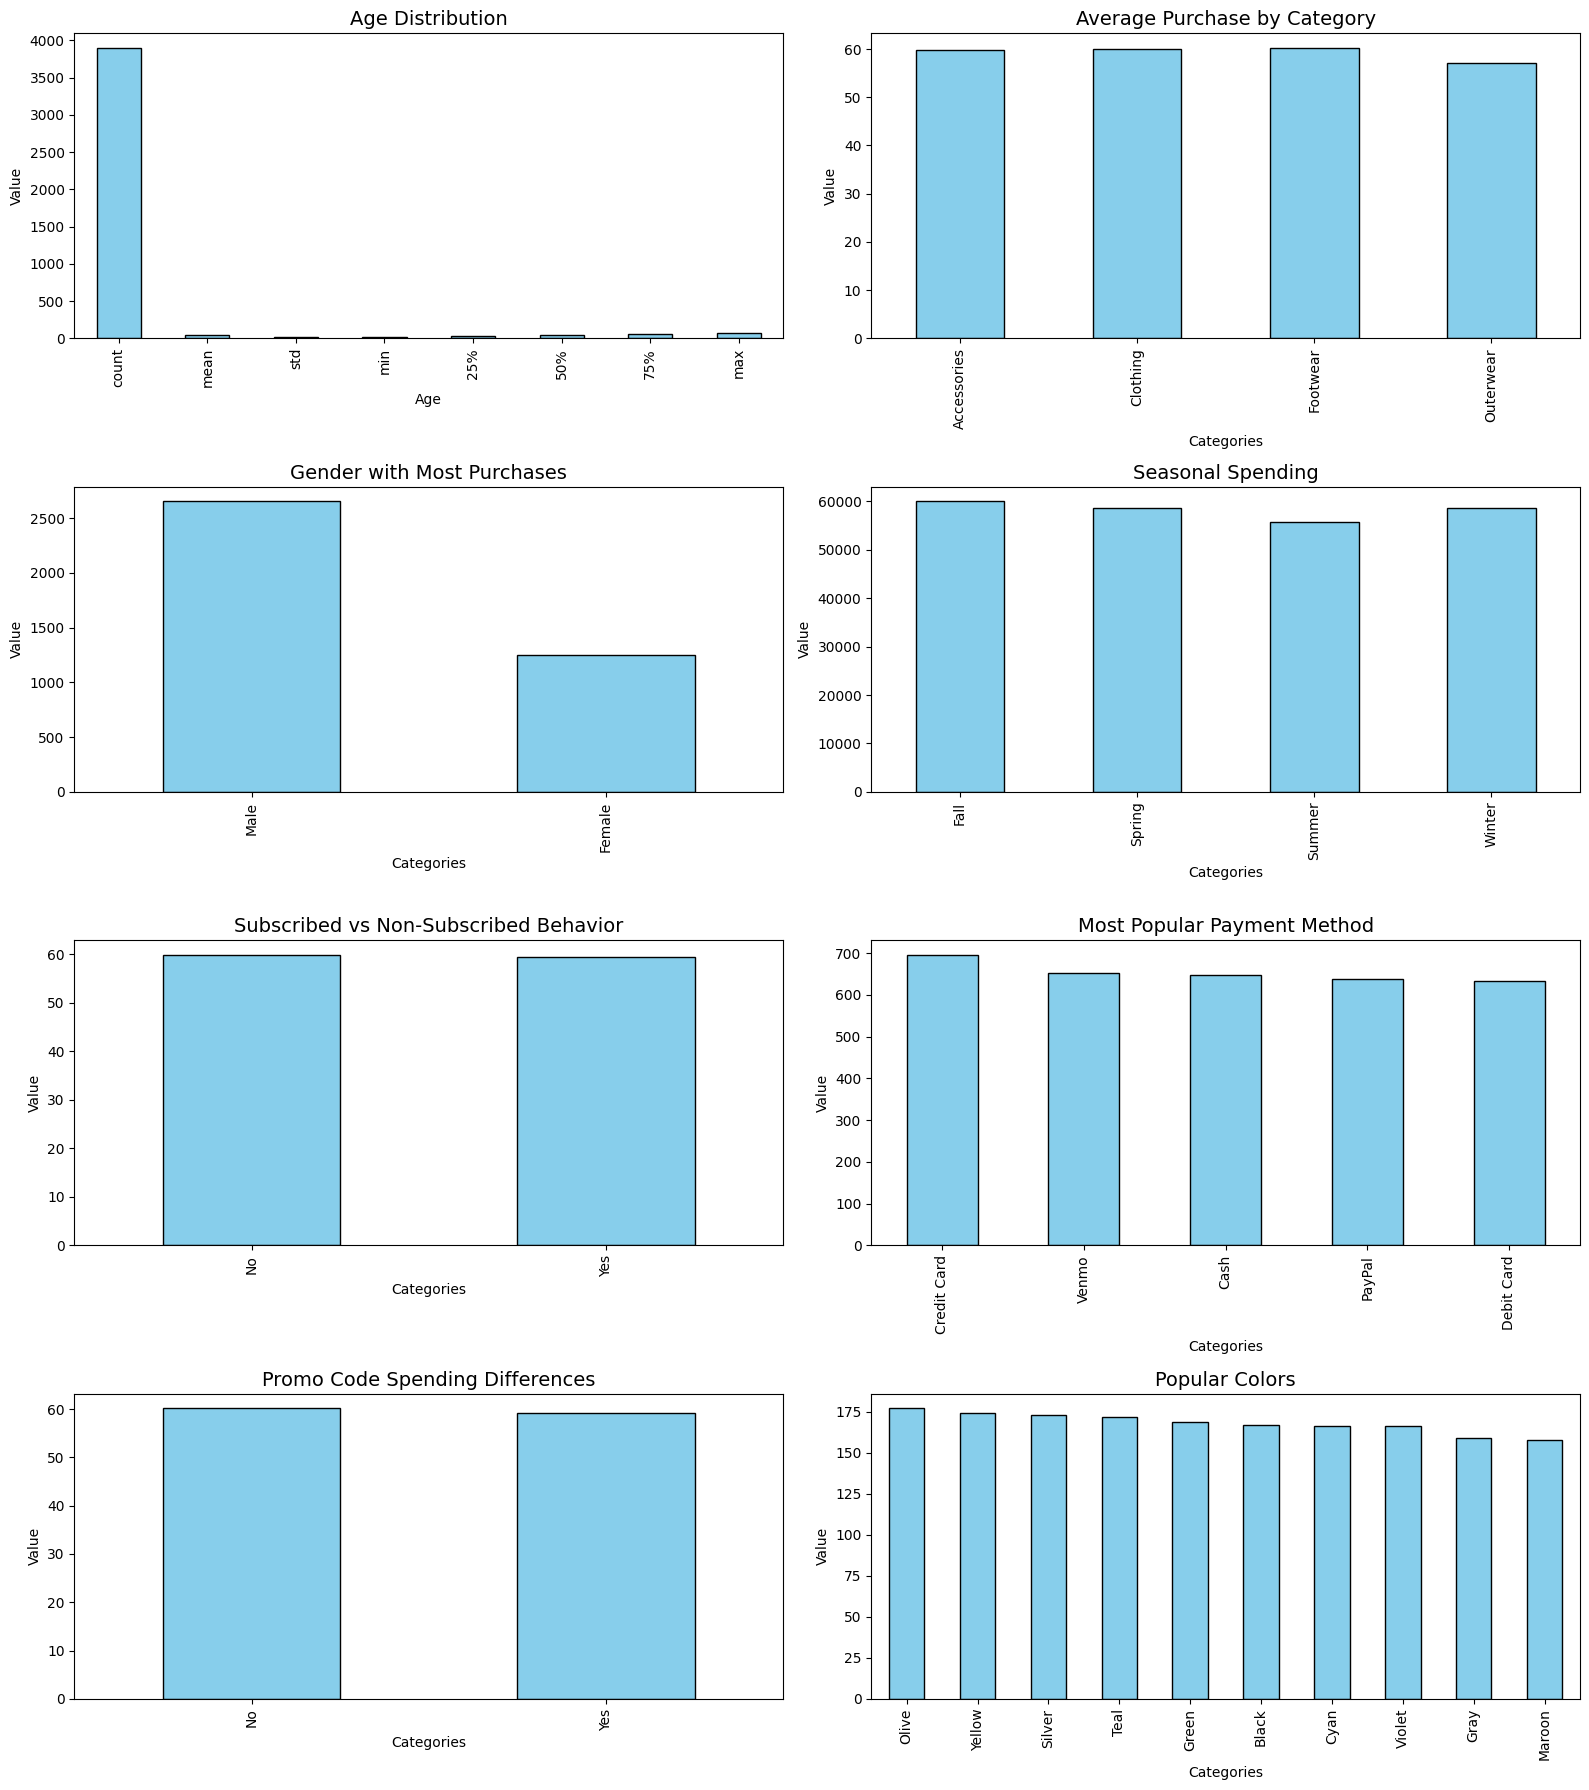

{'Average Purchase by Category': Category
 Accessories    59.838710
 Clothing       60.025331
 Footwear       60.255426
 Outerwear      57.172840
 Name: Purchase Amount (USD), dtype: float64,
 'Seasonal Spending': Season
 Fall      60018
 Spring    58679
 Summer    55777
 Winter    58607
 Name: Purchase Amount (USD), dtype: int64,
 'Subscribed vs Non-Subscribed Behavior': Subscription Status
 No     59.865121
 Yes    59.491928
 Name: Purchase Amount (USD), dtype: float64,
 'Promo Code Spending Differences': Promo Code Used
 No     60.130454
 Yes    59.279070
 Name: Purchase Amount (USD), dtype: float64,
 'Popular Colors (Top 10)': Color
 Olive     177
 Yellow    174
 Silver    173
 Teal      172
 Green     169
 Black     167
 Cyan      166
 Violet    166
 Gray      159
 Maroon    158
 Name: count, dtype: int64}

In [28]:
import matplotlib.pyplot as plt

# Define questions for graphs and tabular outputs
questions_to_plot = {
    "Age Distribution": age_distribution,
    "Average Purchase by Category": avg_purchase_by_category,
    "Gender with Most Purchases": gender_purchase_count,
    "Seasonal Spending": season_spending,
    "Subscribed vs Non-Subscribed Behavior": purchase_behavior_subscription,
    "Most Popular Payment Method": popular_payment_method[:5],  # Top 5 payment methods
    "Promo Code Spending Differences": spending_promo_code,
    "Popular Colors": popular_colors[:10],  # Top 10 colors
}

# Plotting the data
fig, axs = plt.subplots(4, 2, figsize=(16, 18))
axs = axs.flatten()

for idx, (title, data) in enumerate(questions_to_plot.items()):
    if isinstance(data, pd.Series):
        data.plot(kind="bar", ax=axs[idx], color='skyblue', edgecolor='black')
    else:  # For non-series data, we skip plotting
        continue
    axs[idx].set_title(title, fontsize=14)
    axs[idx].set_ylabel("Value")
    axs[idx].set_xlabel("Categories" if idx != 0 else "Age")

# Remove unused subplots
for i in range(len(questions_to_plot), len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout()
plt.show()

# Tabular outputs
tables = {
    "Average Purchase by Category": avg_purchase_by_category,
    "Seasonal Spending": season_spending,
    "Subscribed vs Non-Subscribed Behavior": purchase_behavior_subscription,
    "Promo Code Spending Differences": spending_promo_code,
    "Popular Colors (Top 10)": popular_colors[:10],
}

tables
